# Low-level EEG-to-image reconstruction

This standalone report documents the maintained low-level pipeline. The model maps EEG directly to the latent consumed by the frozen SDXL-Turbo VAE decoder, producing a 128x128 reconstruction. This is the low-level reconstruction stage, not the later diffusion-prior pipeline. All reported test metrics are loaded from the completed external evaluation artifact.

## Protocol and provenance

- Maintained config: `src/brain_image/configs/train_low_level.yaml`
- Training entry point: `scripts/training/train_low_level.py`
- External evaluator: `scripts/evaluation/test_low_level.py`
- Target resolution: 128x128
- Test set: 200 examples
- Evaluation batch size: 1
- Checkpoint selection: lowest validation latent loss

In [1]:
from pathlib import Path
import pandas as pd
import yaml
from IPython.display import display

repo = Path('..').resolve()
run_dir = repo / 'experiments/low_level/20260905_025455/train_low_level-20260905_025524/version_0'
test_dir = run_dir / 'test'
metrics_path = test_dir / 'test_metrics.csv'
config_path = test_dir / 'evaluation_config.yaml'
metrics = pd.read_csv(metrics_path)
evaluation_config = yaml.safe_load(config_path.read_text())
checkpoint_path = Path(evaluation_config['checkpoint_path'])
if not checkpoint_path.is_absolute():
    checkpoint_path = repo / checkpoint_path

assert len(metrics) == 12
assert evaluation_config['dataset']['test_batch_size'] == 1
assert checkpoint_path.exists()
display(pd.DataFrame({
    'artifact': ['checkpoint', 'evaluation CSV', 'evaluation config'],
    'path': [checkpoint_path.relative_to(repo), metrics_path.relative_to(repo), config_path.relative_to(repo)],
}))

,artifact,path
0,checkpoint,experiments/low_level/20260905_025455/train_lo...
1,evaluation CSV,experiments/low_level/20260905_025455/train_lo...
2,evaluation config,experiments/low_level/20260905_025455/train_lo...


In [2]:
standard_metrics = ['test/loss', 'test/losses/l2_loss', 'test/pixcorr', 'test/ssim', 'test/alex2', 'test/alex5', 'test/inceptionv3', 'test/clip', 'test/efficientnet', 'test/swav', 'test/dreamsim_aligned', 'test/dreamsim_unaligned']
assert metrics['metric'].tolist() == standard_metrics
report = metrics.assign(metric=metrics['metric'].str.removeprefix('test/'))
report = report.rename(columns={'metric': 'metric', 'value': 'score'})
display(report.style.format({'score': '{:.5f}'}))

,metric,score
0,loss,0.60728
1,losses/l2_loss,0.60728
2,pixcorr,0.24312
3,ssim,0.36691
4,alex2,0.70161
5,alex5,0.69646
6,inceptionv3,0.54789
7,clip,0.51616
8,efficientnet,0.97387
9,swav,0.75494


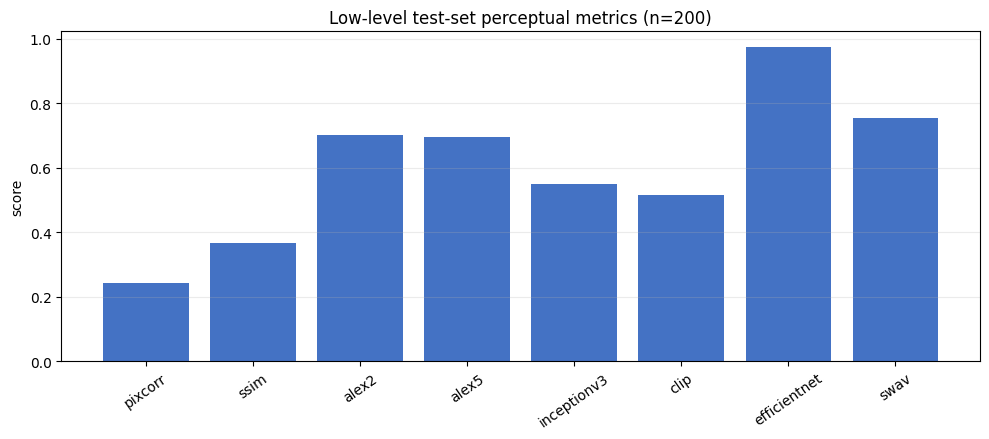

In [3]:
import matplotlib.pyplot as plt

plot_metrics = report[~report['metric'].isin(['loss', 'losses/l2_loss', 'dreamsim_aligned', 'dreamsim_unaligned'])]
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(plot_metrics['metric'], plot_metrics['score'], color='#4472c4')
ax.set_ylabel('score')
ax.set_title('Low-level test-set perceptual metrics (n=200)')
ax.tick_params(axis='x', rotation=35)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

## Interpretation

The low-level baseline reaches PixCorr `0.24312` and SSIM `0.36691`. The evaluator also reports the repository's feature-based identification metrics: AlexNet-2/5 `0.70161/0.69646`, InceptionV3 `0.54789`, CLIP `0.51616`, EfficientNet `0.97387`, and SwAV `0.75494`. DreamSim is retained as an aligned/unaligned diagnostic (`0.78772/0.55785`). EfficientNet and SwAV use the repository's native metric direction and should not be interpreted as ordinary higher-is-better scores without consulting the metric implementation.

No reconstruction image files were emitted by this run, so this report intentionally remains artifact-backed and metric-focused rather than fabricating a visualization from unavailable outputs.